<a href="https://colab.research.google.com/github/gaelBZH/NumericalMethods/blob/main/Laboratory7/Laboratory_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 7 🌍
Gaël Kerninon
---

## **Exercise 1: Manual Calculations**

### **1. Analytical Evaluation**
We want to find the exact value of the integral:
$$I = \int_{1}^{4} x^2 \, dx$$

The antiderivative of $f(x) = x^2$ is $F(x) = \frac{1}{3}x^3$. Using the Fundamental Theorem of Calculus:
$$I = \left[ \frac{1}{3}x^3 \right]_{1}^{4} = \frac{1}{3}(4^3 - 1^3) = \frac{1}{3}(64 - 1) = \frac{63}{3} = 21$$

### **2. Manual Numerical Approximations**

#### **(a) Left Rectangles Method**
$$I_L = h \cdot [f(1) + f(2) + f(3)] = 1 \cdot [1 + 4 + 9] = 14$$
$$\text{Error}_L = \left| \frac{14 - 21}{21} \right| = 33.33\%$$

#### **(b) Right Rectangles Method**
$$I_R = h \cdot [f(2) + f(3) + f(4)] = 1 \cdot [4 + 9 + 16] = 29$$
$$\text{Error}_R = \left| \frac{29 - 21}{21} \right|= 38.10\%$$

#### **(c) Midpoint Rectangles Method**
- Midpoints: $m_1 = 1.5, m_2 = 2.5, m_3 = 3.5$
- $f(1.5) = 2.25, \; f(2.5) = 6.25, \; f(3.5) = 12.25$
$$I_M = h \cdot [f(1.5) + f(2.5) + f(3.5)] = 1 \cdot [2.25 + 6.25 + 12.25] = 20.75$$
**Relative Error:**
$$\text{Error}_M = \left| \frac{20.75 - 21}{21} \right| \times 100\% = 1.19\%$$

#### **(d) Trapezoidal Approximation**
Approximates each subinterval as a trapezoid:
$$I_T = \frac{h}{2} \cdot [f(1) + 2f(2) + 2f(3) + f(4)] = \frac{1}{2} \cdot [1 + 2(4) + 2(9) + 16] = \frac{43}{2} = 21.5$$
$$\text{Error}_T = \left| \frac{21.5 - 21}{21} \right|= 2.38\%$$

### **Manual Results**
| Method | Approximated Value | Exact Value | Absolute Error | Relative Error (%) |
| :--- | :---: | :---: | :---: | :---: |
| **Left Rectangles** | 14.0 | 21.0 | 7.0 | 33.33% |
| **Right Rectangles** | 29.0 | 21.0 | 8.0 | 38.10% |
| **Midpoint Rectangles** | 20.75 | 21.0 | 0.25 | 1.19% |
| **Trapezoidal** | 21.5 | 21.0 | 0.5 | 2.38% |

## **Exercise 2: Python Code**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Initial function given
def f(x):
    return x**2

# Integral of the function calculated using scipy.integrate
def F(a, b):
    if a > b:
        raise ValueError('b must be greater than a')
    elif a == b:
        return 0
    else:
        y = integrate.quad(lambda x: f(x), a, b)
        return y

# Plotting function for a visual representation
def plot_dat(a, b, points, mod='rectangularM'):
    n = np.linspace(a, b, points)
    plt.figure(figsize=(6, 4))
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Numerical approximation: ' + mod)

    if mod == 'rectangularM':
        for i in range(1, len(n)):
            c, d = n[i-1], n[i]
            plt.plot([c, c], [0, f((c+d)/2)], color='blue')
            plt.plot([d, d], [0, f((c+d)/2)], color='blue')
            plt.plot([c, d], [f((c+d)/2), f((c+d)/2)], color='blue')
    elif mod == 'rectangularL':
        for i in range(1, len(n)):
            c, d = n[i-1], n[i]
            plt.plot([c, c], [0, f(c)], color='blue')
            plt.plot([d, d], [0, f(c)], color='blue')
            plt.plot([c, d], [f(c), f(c)], color='blue')
    elif mod == 'rectangularR':
        for i in range(1, len(n)):
            c, d = n[i-1], n[i]
            plt.plot([c, c], [0, f(d)], color='blue')
            plt.plot([d, d], [0, f(d)], color='blue')
            plt.plot([c, d], [f(d), f(d)], color='blue')
    elif mod == 'trapezoidal':
        for i in range(1, len(n)):
            c, d = n[i-1], n[i]
            plt.plot([d, d], [0, f(d)], color='blue')
            plt.plot([c, c], [0, f(c)], color='blue')
            plt.plot([c, d], [f(c), f(d)], color='blue')

    n_dense = np.linspace(a, b, 100)
    plt.plot(n_dense, f(n_dense), color='red', label='$f(x)=x^2$')
    plt.legend()
    plt.show()
    return 0

# Approximating function using numerical methods
def approximateNumerical(a, b, points=10, mod='rectangularM', plt_data=False):
    if points < 2:
        raise ValueError('Number of points must be greater than 2')
    if a == b:
        return 0
    n = np.linspace(a, b, points)
    partialSum = 0
    if mod == 'rectangularM':
        def miniArea(c, d): return (d-c)*f((c+d)/2)
    elif mod == 'rectangularL':
        def miniArea(c, d): return (d-c)*f(c)
    elif mod == 'rectangularR':
        def miniArea(c, d): return (d-c)*f(d)
    elif mod == 'trapezoidal':
        def miniArea(c, d): return (d-c)*(f(c)+f(d))/2
    else:
        raise ValueError('Method ' + mod + ' unknown')

    for i in range(1, len(n)):
        partialSum += miniArea(n[i-1], n[i])

    if plt_data:
        plot_dat(a, b, points, mod)

    return partialSum

### **Cross-checking Point 1**

Actual area (scipy): 21.000000000000004
#############################################################


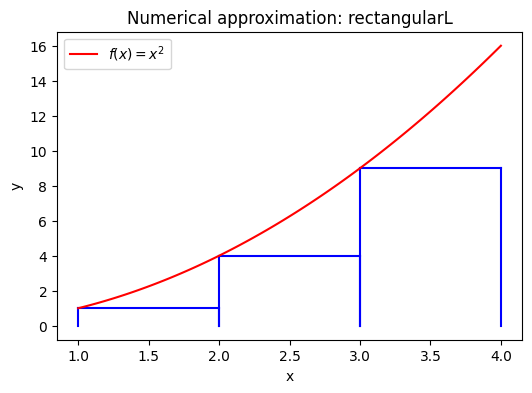

Approximation rectangularL: 14.0000 | Error: 33.3333 %



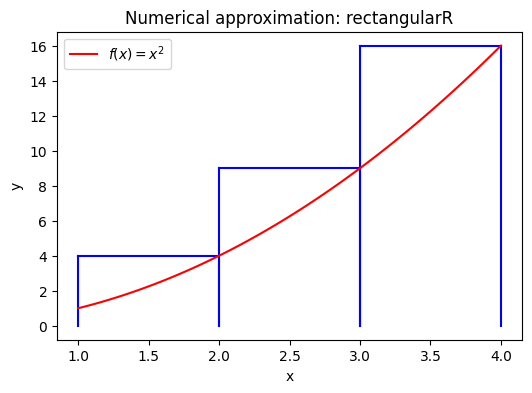

Approximation rectangularR: 29.0000 | Error: 38.0952 %



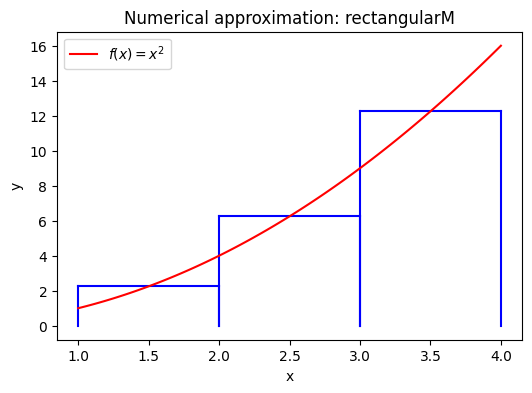

Approximation rectangularM: 20.7500 | Error: 1.1905 %



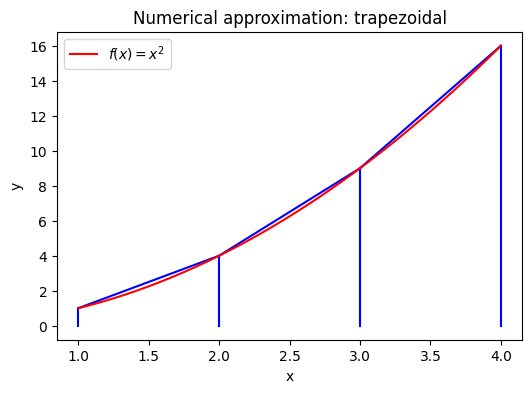

Approximation trapezoidal: 21.5000 | Error: 2.3810 %



In [3]:
m = 1
M = 4
p = 4 # 4 nodes = 3 intervals

actual = F(m, M)[0]
print(f'Actual area (scipy): {actual}')
print('#############################################################')

for method in ['rectangularL', 'rectangularR', 'rectangularM', 'trapezoidal']:
    val = approximateNumerical(m, M, p, mod=method, plt_data=True)
    error = abs((val - actual) / actual) * 100.0
    print(f'Approximation {method}: {val:.4f} | Error: {error:.4f} %\n')

The code results perfectly match the manual calculations:
- Left Rectangles: **14.0000** (Error: 33.3333%)
- Right Rectangles: **29.0000** (Error: 38.0952%)
- Midpoint Rectangles: **20.7500** (Error: 1.1905%)
- Trapezoidal: **21.5000** (Error: 2.3810%)

---

## **Task 3: Numerical Integration of $\int_{-1}^{3} \exp(-x^{2}) \, dx$**

In [9]:
def f(x):
    return np.exp(-x**2)

a, b = -1, 3
actual_exp = integrate.quad(lambda x: np.exp(-x**2), a, b)[0]
print(f"Exact scipy integral value: {actual_exp:.10f}")

Exact scipy integral value: 1.6330314811


### **Precision Dependency Tests**

In [10]:
node_counts = [4, 10, 20, 50, 100, 200, 500]
methods = ['rectangularL', 'rectangularR', 'rectangularM', 'trapezoidal']
results = {m: [] for m in methods}

for p in node_counts:
    for method in methods:
        val = approximateNumerical(a, b, p, mod=method, plt_data=False)
        err = abs((val - actual_exp) / actual_exp) * 100.0
        results[method].append(err)

# Print Results
print(f"{'Nodes':<8} | {'Left Rect %':<13} | {'Right Rect %':<13} | {'Midpoint %':<13} | {'Trapezoidal %':<13}")
print("-"*75)
for i, p in enumerate(node_counts):
    print(f"{p:<8} | {results['rectangularL'][i]:<13.5f} | {results['rectangularR'][i]:<13.5f} | {results['rectangularM'][i]:<13.5f} | {results['trapezoidal'][i]:<13.5f}")

Nodes    | Left Rect %   | Right Rect %  | Midpoint %    | Trapezoidal %
---------------------------------------------------------------------------
4        | 8.17471       | 21.85174      | 3.45087       | 6.83852      
10       | 4.25726       | 5.75155       | 0.37535       | 0.74714      
20       | 2.20369       | 2.53733       | 0.08350       | 0.16682      
50       | 0.89413       | 0.94423       | 0.01253       | 0.02505      
100      | 0.44881       | 0.46108       | 0.00307       | 0.00614      
200      | 0.22481       | 0.22785       | 0.00076       | 0.00152      
500      | 0.09002       | 0.09050       | 0.00012       | 0.00024      


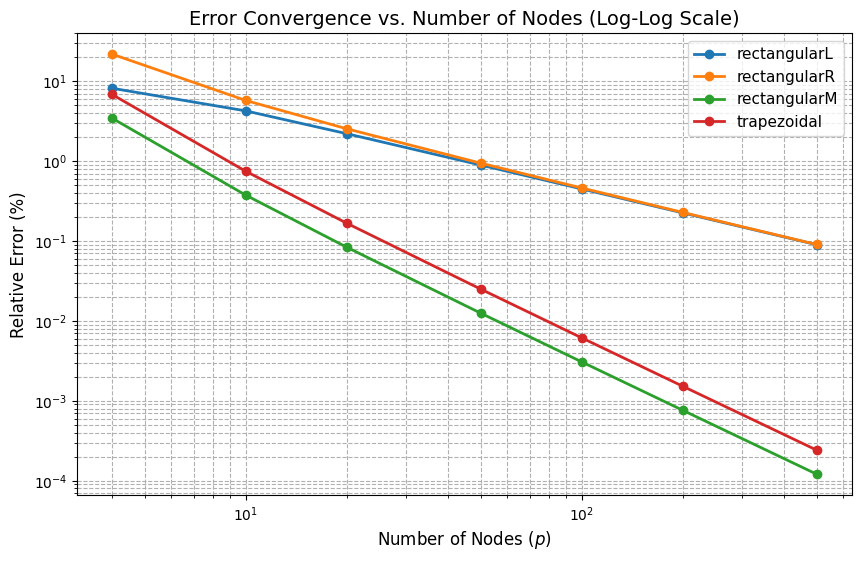

In [11]:
# Plotting
plt.figure(figsize=(10, 6))
for method in methods:
    plt.plot(node_counts, results[method], 'o-', label=method, linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Nodes ($p$)', fontsize=12)
plt.ylabel('Relative Error (%)', fontsize=12)
plt.title('Error Convergence vs. Number of Nodes (Log-Log Scale)', fontsize=14)
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=11)
plt.show()

### Conclusion
Increasing the number of nodes improves precision across all methods by reducing step size, but efficiency depends on their convergence order.

Left and Right rectangles exhibit low-accuracy
Trapezoidal and Midpoint methods offer much higher precision with good convergence
Because the Midpoint method yields the highest accuracy for this Gaussian function, it—or the Trapezoidal method—should always be preferred over endpoint rectangles to optimize both computation time and precision.